# JWST MIRI False-Color Composite of M42

This notebook builds an RGB false-color image from three JWST MIRI imaging filters of the Orion Nebula (M42), observed as part of the PDRs4All Early Release Science program (PID 1288).

**Filter-to-channel mapping** (standard infrared convention — longer wavelength → redder color):

| Channel | Filter | Wavelength |
|---------|--------|------------|
| Blue    | F770W  | 7.7 µm    |
| Green   | F1500W | 15.0 µm   |
| Red     | F2550W | 25.5 µm   |

In [28]:
from astropy.io import fits 
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import numpy as np
import os
import re
import glob
import json

# Read target and filters from the config saved by Working_draft.ipynb
with open("target_config.json") as cfg:
    config = json.load(cfg)
target_name = config["target_name"]
target_filters = config["target_filters"]
print(f"Target: {target_name}, Filters: {target_filters}")

fits_dir = f"./fits_images/{target_name}" #builds the path to the folder where the fits files live

# Auto-discover FITS files by scanning the target folder and matching filter names
fits_files = {}
for fpath in sorted(glob.glob(os.path.join(fits_dir, "*_i2d.fits"))):
    fname = os.path.basename(fpath).lower()
    m = re.search(r"_f(\d+w)", fname)
    if m:
        detected_filter = f"F{m.group(1).upper()}"
        if detected_filter in target_filters:
            fits_files[detected_filter] = fpath

for f in target_filters:
    if f in fits_files:
        print(f"  {f}: OK  ({fits_files[f]})")
    else:
        print(f"  WARNING: {f}: MISSING — no matching file found in {fits_dir}")

missing = [f for f in target_filters if f not in fits_files]
if missing:
    all_on_disk = []
    for fpath in sorted(glob.glob(os.path.join(fits_dir, "*_i2d.fits"))):
        m = re.search(r"_f(\d+w)", os.path.basename(fpath).lower())
        if m:
            all_on_disk.append(f"F{m.group(1).upper()}")
    print(f"\n  Filters available on disk: {all_on_disk or 'none'}")
    print(f"  Filters requested but missing: {missing}")

# Update target_filters to only include what we actually have
target_filters = [f for f in target_filters if f in fits_files]
n_bands = len(target_filters)
if n_bands == 0:
    raise SystemExit(f"ERROR: No matching FITS files found in {fits_dir}")
elif n_bands < 3:
    print(f"\n  Only {n_bands} filter(s) found — will adapt display accordingly.")

Target: M74, Filters: ['F770W', 'F1500W', 'F2550W']
  F770W: OK  (./fits_images/M74/jw01783-o908_t016_miri_f770w_i2d.fits)
  F1500W: OK  (./fits_images/M74/jw02666-o007_t004_miri_f1500w_i2d.fits)
  F2550W: OK  (./fits_images/M74/jw02666-o007_t004_miri_f2550w_i2d.fits)


## Load, Clean, and Align the Three Bands

1. **Pandas DataFrame** — organizes the filters by wavelength and assigns each to an RGB channel.
2. **FITS loading** — reads the 2-D science image from each `_i2d.fits` file.
3. **NaN filling** — replaces missing-coverage pixels (from incomplete dither overlap) with the nearest valid pixel value.
4. **North-up reprojection** — the MIRI detector was rotated ~87° on the sky; all bands are reprojected onto a common North-up, East-left WCS grid so the image appears upright.

In [29]:
import pandas as pd
from reproject import reproject_interp

# --- Build a pandas DataFrame of our three bands ---
rows = []
for f in target_filters:
    path = fits_files[f]
    rows.append({
        "filter": f,
        "wavelength_um": float(f.replace("F", "").replace("W", "")) / 100,
        "filename": os.path.basename(path),
        "path": path,
    })

bands_df = pd.DataFrame(rows).sort_values("wavelength_um").reset_index(drop=True)
n_bands = len(bands_df)
if n_bands == 3:
    bands_df["rgb_channel"] = ["B", "G", "R"]
elif n_bands == 2:
    bands_df["rgb_channel"] = ["B", "R"]  # shortest→blue, longest→red, green=average
    print("  2 filters: green channel will be synthesized as average of the two.")
elif n_bands == 1:
    bands_df["rgb_channel"] = ["mono"]
    print("  1 filter: will display as single-band image with colormap.")
print(bands_df.to_string(index=False))

# --- Load each band's 2-D image and its WCS ---
images, headers = {}, {}
for _, row in bands_df.iterrows():
    hdul = fits.open(row["path"])
    ext = "SCI" if "SCI" in [h.name for h in hdul] else 1
    data = np.squeeze(hdul[ext].data)
    if data.ndim == 3:
        data = np.nansum(data, axis=0)
    images[row["filter"]] = data
    headers[row["filter"]] = hdul[ext].header
    hdul.close()

bands_df["shape"] = [images[f].shape for f in bands_df["filter"]]
print("\nLoaded shapes:")
print(bands_df[["filter", "rgb_channel", "shape"]].to_string(index=False))

# --- Fill NaN gaps via nearest-neighbor interpolation ---
from scipy.ndimage import distance_transform_edt

def fill_nans(data):
    """Replace NaN pixels with the nearest valid pixel value."""
    mask = np.isnan(data)
    if not mask.any():
        return data
    ind = distance_transform_edt(mask, return_distances=False, return_indices=True)
    return data[tuple(ind)]

for f in images:
    before = np.isnan(images[f]).sum()
    images[f] = fill_nans(images[f])
    print(f"  {f}: filled {before} NaN pixels")

# --- Build a North-up WCS so the image isn't rotated ---
ref_filter = bands_df.iloc[0]["filter"]
orig_wcs = WCS(headers[ref_filter], naxis=2)
ny, nx = images[ref_filter].shape

# Pixel scale from the original WCS (degrees/pixel)
pixscale = np.sqrt(np.abs(np.linalg.det(orig_wcs.wcs.pc))) * np.abs(orig_wcs.wcs.cdelt[0])

# Sky center of the original image
center_sky = orig_wcs.pixel_to_world(nx / 2, ny / 2)

# Pad output a bit so no corners are clipped after rotation
diag = int(np.ceil(np.sqrt(nx**2 + ny**2)))
out_ny, out_nx = diag, diag

ref_wcs = WCS(naxis=2)
ref_wcs.wcs.crpix = [out_nx / 2, out_ny / 2]
ref_wcs.wcs.crval = [center_sky.ra.deg, center_sky.dec.deg]
ref_wcs.wcs.cdelt = [-pixscale, pixscale]   # North up, East left
ref_wcs.wcs.pc = [[1, 0], [0, 1]]           # no rotation
ref_wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
ref_shape = (out_ny, out_nx)

# --- Reproject all bands onto the North-up grid ---
aligned = {}
for _, row in bands_df.iterrows():
    f = row["filter"]
    src_wcs = WCS(headers[f], naxis=2)
    reprojected, footprint = reproject_interp(
        (images[f], src_wcs), ref_wcs, shape_out=ref_shape
    )
    reprojected[~np.isfinite(reprojected)] = 0
    aligned[f] = reprojected

print(f"\nAll bands reprojected to North-up grid ({ref_shape[0]}×{ref_shape[1]} px)")

filter  wavelength_um                               filename                                                     path rgb_channel
 F770W            7.7  jw01783-o908_t016_miri_f770w_i2d.fits  ./fits_images/M74/jw01783-o908_t016_miri_f770w_i2d.fits           B
F1500W           15.0 jw02666-o007_t004_miri_f1500w_i2d.fits ./fits_images/M74/jw02666-o007_t004_miri_f1500w_i2d.fits           G
F2550W           25.5 jw02666-o007_t004_miri_f2550w_i2d.fits ./fits_images/M74/jw02666-o007_t004_miri_f2550w_i2d.fits           R

Loaded shapes:
filter rgb_channel        shape
 F770W           B (1073, 3469)
F1500W           G (1171, 1178)
F2550W           R (1171, 1178)
  F770W: filled 404890 NaN pixels
  F1500W: filled 329637 NaN pixels
  F2550W: filled 330677 NaN pixels


Set OBSGEO-B to     7.901160 from OBSGEO-[XYZ].
Set OBSGEO-H to 1682892732.929 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     7.901160 from OBSGEO-[XYZ].
Set OBSGEO-H to 1682892732.929 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -36.441794 from OBSGEO-[XYZ].
Set OBSGEO-H to 1720827575.014 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -36.435075 from OBSGEO-[XYZ].
Set OBSGEO-H to 1720774916.686 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]



All bands reprojected to North-up grid (3632×3632 px)


## Stretch, Enhance, and Display

- **Gaussian smoothing** (σ = 0.8 px) reduces single-pixel noise before the nonlinear stretch.
- **Arcsinh stretch** compresses the large dynamic range so both bright stars and faint nebulosity are visible.
- **Saturation boost** amplifies color differences between channels for a more vivid composite.
- The final image is **cropped** to the overlap region of all three bands and displayed on a dark background.

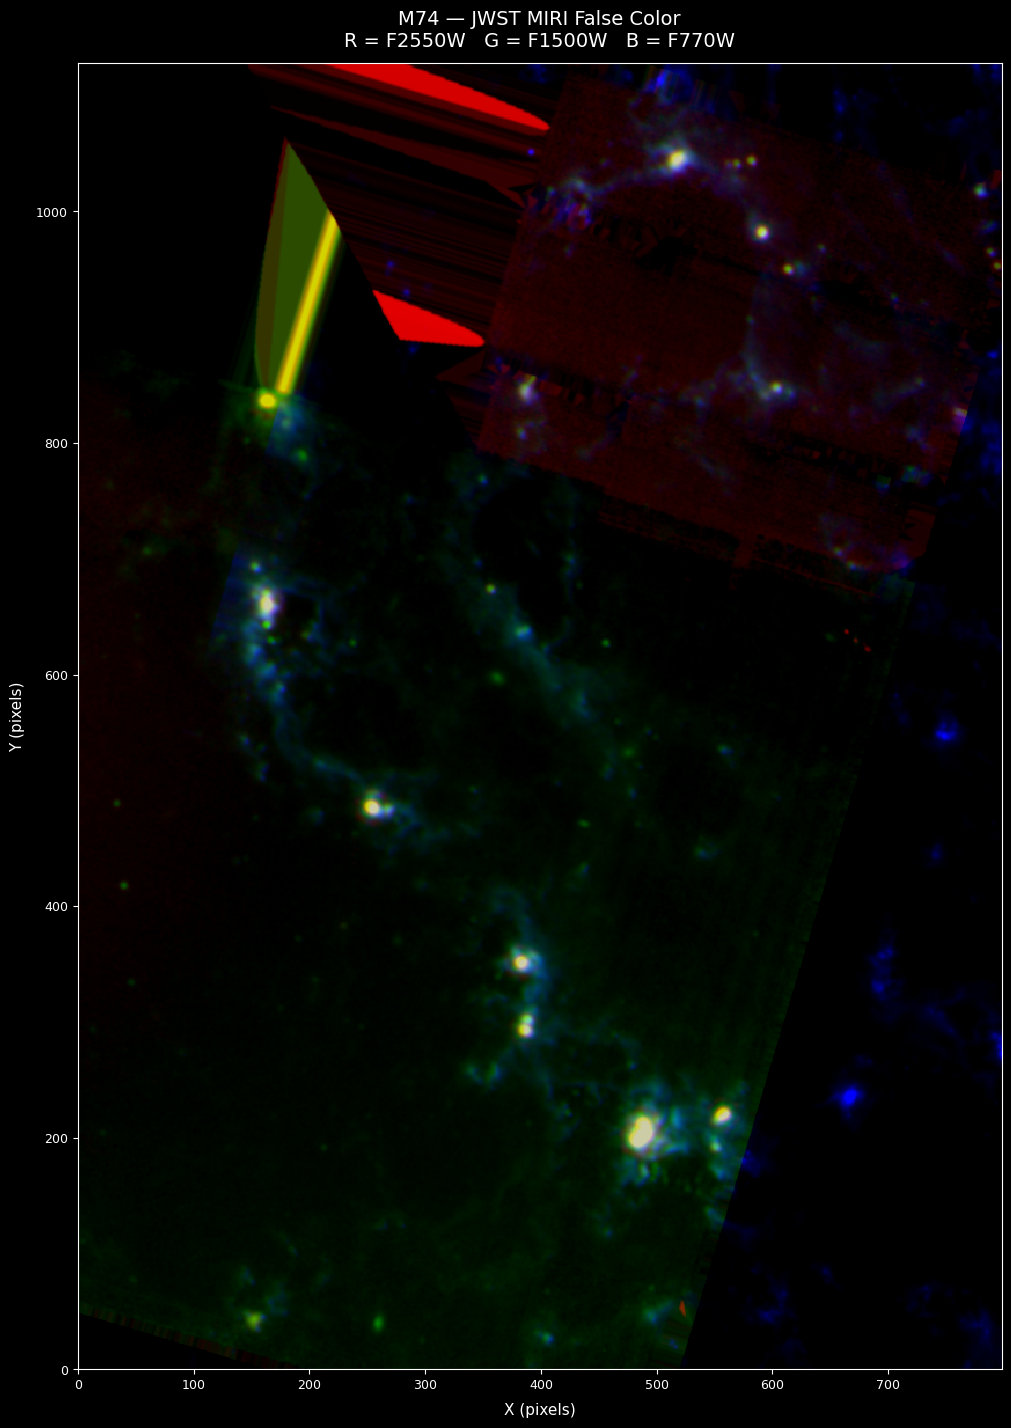

Saved M74_false_color.png (300 DPI)


In [31]:
from scipy.ndimage import gaussian_filter

def subtract_background(img):
    """Subtract the median background so thermal pedestal doesn't dominate."""
    valid = img[img > 0]
    if len(valid) == 0:
        return img
    bg = np.median(valid)
    return np.clip(img - bg, 0, None)

def stretch(img, lo=0.5, hi=99.8, gain=5):
    """Background-subtract, then arcsinh stretch normalized to 0-1."""
    img = np.nan_to_num(img, nan=0.0)
    img = subtract_background(img)
    pos = img[img > 0]
    if len(pos) == 0:
        return np.zeros_like(img)
    vmin = np.percentile(pos, lo)
    vmax = np.percentile(pos, hi)
    normed = np.clip((img - vmin) / (vmax - vmin), 0, 1)
    return np.arcsinh(normed * gain) / np.arcsinh(gain)

def boost_saturation(rgb, factor=1.4):
    """Boost color saturation while preserving luminance."""
    lum = 0.2126 * rgb[:,:,0] + 0.7152 * rgb[:,:,1] + 0.0722 * rgb[:,:,2]
    boosted = np.empty_like(rgb)
    for i in range(3):
        boosted[:,:,i] = lum + factor * (rgb[:,:,i] - lum)
    return np.clip(boosted, 0, 1)

channel_map = bands_df.set_index("rgb_channel")["filter"]
sigma = 0.8
n_bands = len(bands_df)

if n_bands == 3:
    r = stretch(gaussian_filter(aligned[channel_map["R"]], sigma=sigma))
    g = stretch(gaussian_filter(aligned[channel_map["G"]], sigma=sigma))
    b = stretch(gaussian_filter(aligned[channel_map["B"]], sigma=sigma))
    rgb = np.stack([r, g, b], axis=-1)
    rgb = boost_saturation(rgb, factor=1.5)
    subtitle = f"R = {channel_map['R']}   G = {channel_map['G']}   B = {channel_map['B']}"

elif n_bands == 2:
    r = stretch(gaussian_filter(aligned[channel_map["R"]], sigma=sigma))
    b = stretch(gaussian_filter(aligned[channel_map["B"]], sigma=sigma))
    g = (r + b) / 2
    rgb = np.stack([r, g, b], axis=-1)
    rgb = boost_saturation(rgb, factor=1.5)
    subtitle = f"R = {channel_map['R']}   G = synthetic   B = {channel_map['B']}"

else:
    mono = stretch(gaussian_filter(aligned[channel_map["mono"]], sigma=sigma))
    rgb = None
    subtitle = f"Filter: {channel_map['mono']}"

if rgb is not None:
    any_data = np.any(rgb > 0, axis=-1)
    rows_any = np.where(any_data.any(axis=1))[0]
    cols_any = np.where(any_data.any(axis=0))[0]
    if len(rows_any) > 0 and len(cols_any) > 0:
        rgb = rgb[rows_any[0]:rows_any[-1]+1, cols_any[0]:cols_any[-1]+1]
    ny, nx = rgb.shape[:2]
else:
    rows_any = np.where((mono > 0).any(axis=1))[0]
    cols_any = np.where((mono > 0).any(axis=0))[0]
    if len(rows_any) > 0 and len(cols_any) > 0:
        mono = mono[rows_any[0]:rows_any[-1]+1, cols_any[0]:cols_any[-1]+1]
    ny, nx = mono.shape

fig_w = 10
fig_h = max(fig_w * ny / nx + 1.4, 6)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), constrained_layout=True)
    if rgb is not None:
        ax.imshow(rgb, origin="lower", interpolation="nearest",
                  aspect="equal", extent=(0, nx, 0, ny))
    else:
        im = ax.imshow(mono, origin="lower", interpolation="nearest",
                       aspect="equal", extent=(0, nx, 0, ny), cmap="inferno")
        plt.colorbar(im, ax=ax, label="Flux (stretched)", shrink=0.8)
    ax.set_xlim(0, nx)
    ax.set_ylim(0, ny)
    ax.set_xlabel("X (pixels)", fontsize=11, labelpad=8)
    ax.set_ylabel("Y (pixels)", fontsize=11, labelpad=8)
    mode_label = "False Color" if n_bands >= 2 else "Single Band"
    ax.set_title(
        f"{target_name} — JWST MIRI {mode_label}\n{subtitle}",
        fontsize=14, pad=12, color="white",
    )
    ax.tick_params(colors="white", labelsize=9)
    fig.savefig(
        f"{target_name}_false_color.png",
        dpi=300, bbox_inches="tight", facecolor="black", pad_inches=0.08,
    )
    plt.show()

print(f"Saved {target_name}_false_color.png (300 DPI)")